In [1]:
import pandas as pd

path = 'yandex_arhangelsk_rent.csv'

df = pd.read_csv(path, sep=',')

df.head()

,offer_id,url,rooms,price_month,deposit,latitude,longitude,area_total,floor,floors_total,building_year,area_living,area_kitchen,ceiling_height
0,1106637747842887169,https://realty.yandex.ru/offer/110663774784288...,2.0,50000,0.0,64.586720,40.515663,90.0,1,3,2000.0,NaN,NaN,NaN
1,1198973562525317120,https://realty.yandex.ru/offer/119897356252531...,2.0,22000,5000.0,64.547195,40.573948,54.0,5,9,1974.0,32.0,7.0,2.7
2,1232837691192031745,https://realty.yandex.ru/offer/123283769119203...,1.0,32000,15000.0,64.554110,40.537450,43.8,6,9,2008.0,20.0,13.8,NaN
3,1360453884302373588,https://realty.yandex.ru/offer/136045388430237...,2.0,26000,0.0,64.527380,40.603420,51.8,3,10,2002.0,30.4,7.8,NaN
4,1562632997629356289,https://realty.yandex.ru/offer/156263299762935...,1.0,22000,0.0,64.489840,40.717400,37.0,2,7,2011.0,18.0,8.0,NaN


In [2]:
df["rooms"] = df["rooms"].fillna(0)

df.to_csv('arhangelsk_rent.csv', index=False)

In [15]:
import pandas as pd

df = pd.read_csv('arhangelsk_rent.csv')

print(f'Размер датасета {df.shape}')

Размер датасета (125, 14)


In [5]:
df.dtypes

offer_id            int64
url                object
rooms             float64
price_month         int64
deposit           float64
latitude          float64
longitude         float64
area_total        float64
floor               int64
floors_total        int64
building_year     float64
area_living       float64
area_kitchen      float64
ceiling_height    float64
dtype: object

In [16]:
df.isnull().sum()

offer_id           0
url                0
rooms              0
price_month        0
deposit           32
latitude           0
longitude          0
area_total         0
floor              0
floors_total       0
building_year      6
area_living        5
area_kitchen      21
ceiling_height    52
dtype: int64

In [ ]:
import numpy as np

def clean_rent_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """Очищает и заполняет пропуски в датасете аренды квартир."""
    df_clean = df.copy()

    # 1. Заполнение deposit (пропуск = 0)
    df_clean['deposit'] = df_clean['deposit'].fillna(0)

    # 2. Заполнение area_living и area_kitchen (по пропорции от area_total внутри категорий rooms)
    # Считаем медианное отношение площадей к общей площади для каждой группы комнат
    living_ratios = (
        df_clean['area_living'] / df_clean['area_total']
    ).groupby(df_clean['rooms']).transform('median')
    kitchen_ratios = (
        df_clean['area_kitchen'] / df_clean['area_total']
    ).groupby(df_clean['rooms']).transform('median')

    # Если в какой-то редкой группе пропуски по всей группе, fallback на общую медиану
    living_ratios = living_ratios.fillna(
        (df_clean['area_living'] / df_clean['area_total']).median()
    )
    kitchen_ratios = kitchen_ratios.fillna(
        (df_clean['area_kitchen'] / df_clean['area_total']).median()
    )

    df_clean['area_living'] = df_clean['area_living'].fillna(
        df_clean['area_total'] * living_ratios
    )
    df_clean['area_kitchen'] = df_clean['area_kitchen'].fillna(
        df_clean['area_total'] * kitchen_ratios
    )

    # 3. Заполнение building_year (по медиане этажности floors_total)
    df_clean['building_year'] = df_clean['building_year'].fillna(
        df_clean.groupby('floors_total')['building_year'].transform('median')
    )
    # Запасной вариант общей медианой (если у этой этажности нет аналогов с годом)
    df_clean['building_year'] = df_clean['building_year'].fillna(
        df_clean['building_year'].median()
    )
    df_clean['building_year'] = df_clean['building_year'].round().astype(int)

    # 4. Заполнение ceiling_height (создаем индикатор и заполняем медианой по числу комнат)
    df_clean = df_clean.drop(columns=['ceiling_height'])

    return df_clean


# Использование:
df = clean_rent_dataset(df)

In [22]:
df.isnull().sum()

offer_id         0
url              0
rooms            0
price_month      0
deposit          0
latitude         0
longitude        0
area_total       0
floor            0
floors_total     0
building_year    0
area_living      0
area_kitchen     0
dtype: int64

In [25]:
df['rooms'] = df['rooms'].astype(int)
df['price_month'] = df['price_month'].astype(float)
df['building_year'] = df['building_year'].astype(int)

In [26]:
print("Число дубликатов:", df.duplicated().sum())

Число дубликатов: 0


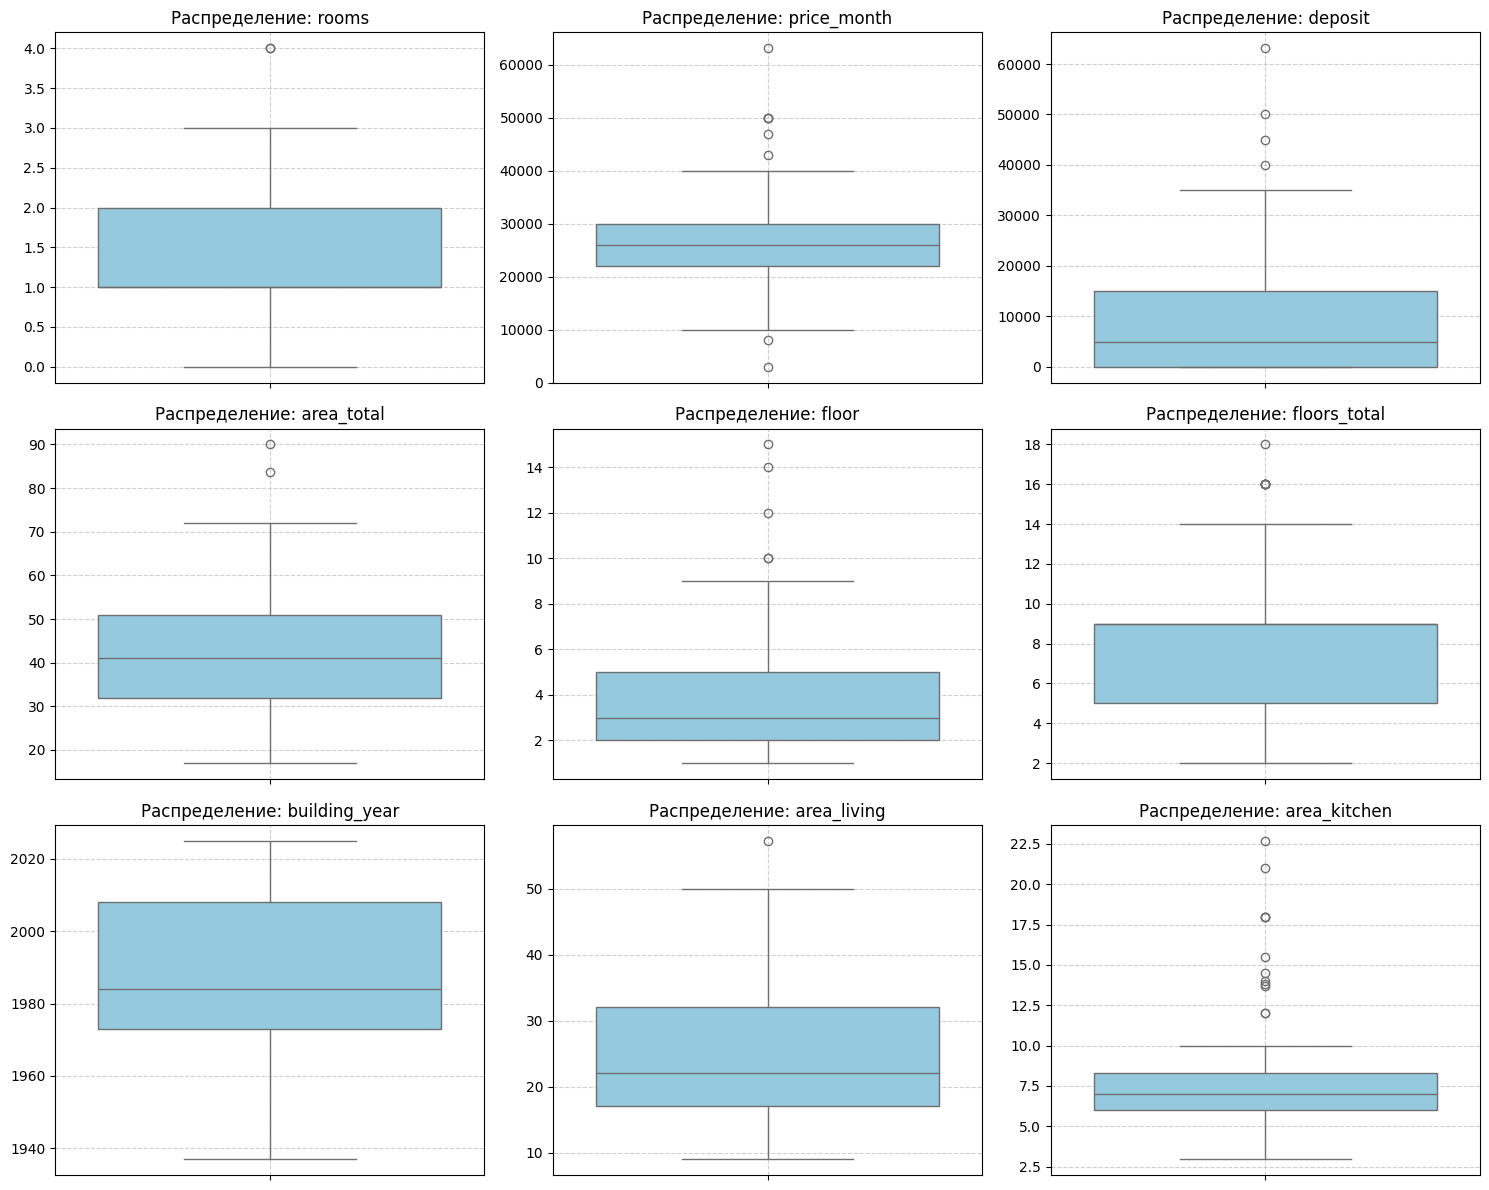

In [28]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Выбираем числовые столбцы и исключаем технические (ID, координаты, ссылки)
exclude_cols = ['offer_id', 'latitude', 'longitude', 'url']
numeric_cols = [
    col
    for col in df.select_dtypes(include=['number']).columns
    if col not in exclude_cols
]

# 2. Настраиваем сетку графиков
num_cols = len(numeric_cols)
cols_per_row = 3  # Количество графиков в одной строке
rows = math.ceil(num_cols / cols_per_row)

fig, axes = plt.subplots(
    rows, cols_per_row, figsize=(15, 4 * rows), squeeze=False
)
axes = axes.flatten()

# 3. Строим boxplot для каждого столбца
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Распределение: {col}', fontsize=12)
    axes[i].set_ylabel('')
    axes[i].grid(True, linestyle='--', alpha=0.6)

# 4. Прячем пустые графики, если количество столбцов не кратно cols_per_row
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [29]:
df.to_csv('arhangelsk_rent_cleaned.csv', index=False)